In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/Ikeoluwapo/Gene-Expression/main/gene_expression.csv"

df = pd.read_csv(url)

In [3]:
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gene One        3000 non-null   float64
 1   Gene Two        3000 non-null   float64
 2   Cancer Present  3000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 70.4 KB


In [5]:
df.isnull().sum()

Gene One          0
Gene Two          0
Cancer Present    0
dtype: int64

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Gene One,3000.0,5.600133,1.828388,1.0,4.3,5.6,6.9,10.0
Gene Two,3000.0,5.410467,1.729081,1.0,4.0,5.4,6.7,10.0
Cancer Present,3000.0,0.500000,0.500083,0.0,0.0,0.5,1.0,1.0


In [7]:
df['Cancer Present'].value_counts()

Cancer Present
1    1500
0    1500
Name: count, dtype: int64

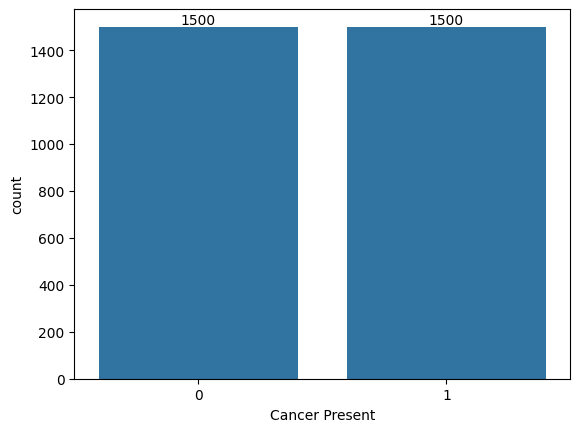

In [8]:
sns.countplot(data=df, x='Cancer Present').bar_label(plt.gca().containers[0]);

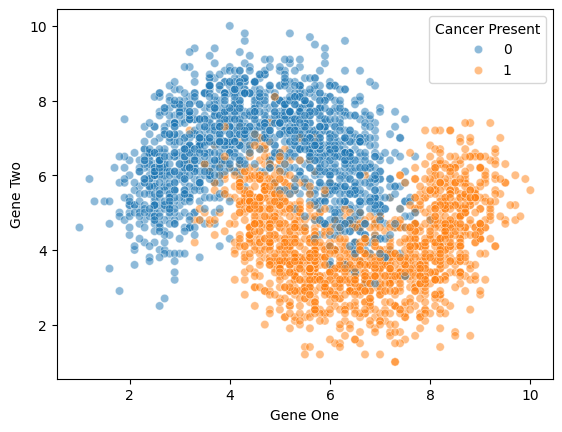

In [9]:
sns.scatterplot(data=df, x ='Gene One', y = 'Gene Two', 
                hue='Cancer Present', alpha=0.5);

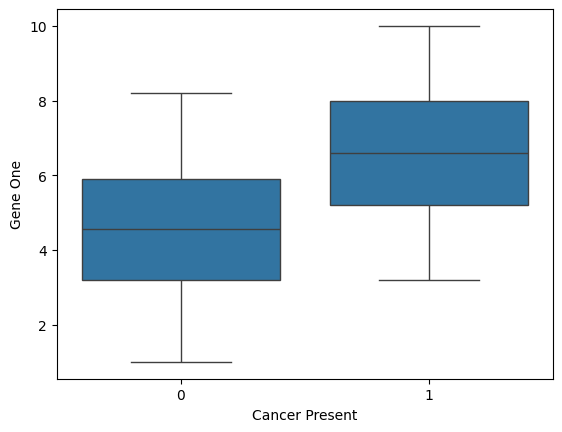

In [10]:
##GENE ONE
sns.boxplot(data=df,x='Cancer Present', y='Gene One');

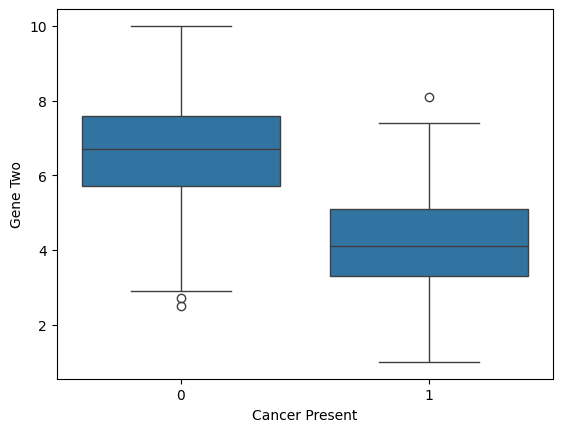

In [11]:
# GENE TWO
sns.boxplot(data=df,x='Cancer Present', y='Gene Two');

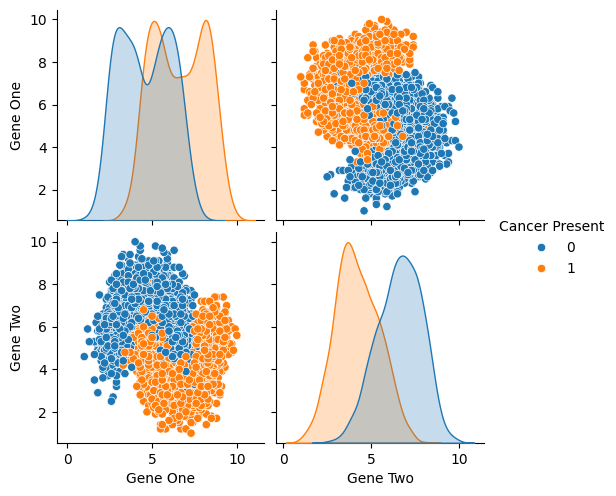

In [12]:
sns.pairplot(data =df, hue='Cancer Present', diag_kind='kde');

In [13]:
df.corr()

,Gene One,Gene Two,Cancer Present
Gene One,1.000000,-0.375427,0.545854
Gene Two,-0.375427,1.000000,-0.692352
Cancer Present,0.545854,-0.692352,1.000000


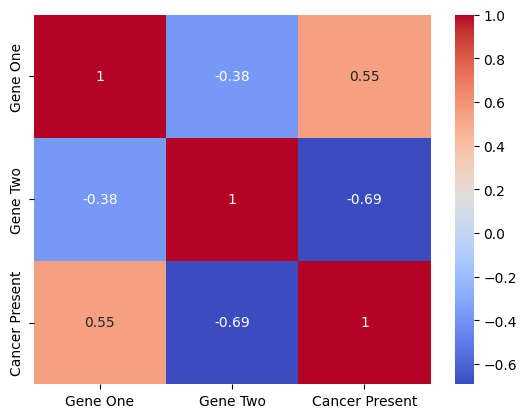

In [14]:
sns.heatmap(df.corr(), cmap='coolwarm',annot =True);

In [15]:
## BUILD THE MACHINE LEARNING MODEL
df.shape

(3000, 3)

In [16]:
X = df.drop("Cancer Present", axis =1)
y = df["Cancer Present"]

In [17]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3,
                                                    random_state=42)

In [19]:
knn = KNeighborsClassifier()

In [20]:
knn.get_params().keys()

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

In [21]:
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',KNeighborsClassifier())
    ])

In [22]:
k_values = list(range(1,20)) 
param_grid ={
    'knn__n_neighbors': k_values,
    'knn__metric':['minkowski']
}

#parameter grid inside pipeline naming is 'str_name_chosen'+'__'+'param_name'

In [23]:
knn_classifier = GridSearchCV(knn_pipe, param_grid, cv =5,
                              scoring = 'accuracy',n_jobs=-1)

In [24]:
knn_classifier.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__metric': ['minkowski'],
                         'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19]},
             scoring='accuracy')

In [25]:
knn_classifier.best_estimator_.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('knn', KNeighborsClassifier(n_neighbors=14))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'knn': KNeighborsClassifier(n_neighbors=14),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'knn__algorithm': 'auto',
 'knn__leaf_size': 30,
 'knn__metric': 'minkowski',
 'knn__metric_params': None,
 'knn__n_jobs': None,
 'knn__n_neighbors': 14,
 'knn__p': 2,
 'knn__weights': 'uniform'}

In [26]:
y_pred_knn = knn_classifier.predict(X_test)

In [27]:
from sklearn.metrics import classification_report

In [28]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       470
           1       0.95      0.92      0.94       430

    accuracy                           0.94       900
   macro avg       0.94      0.94      0.94       900
weighted avg       0.94      0.94      0.94       900



In [29]:
# TEST PATIENT with Gene Values
new_patient = pd.DataFrame([[3.9, 5.8]], columns=['Gene One', 'Gene Two'])
new_patient

,Gene One,Gene Two
0,3.9,5.8


In [30]:
knn_classifier.predict(new_patient)

array([1])

In [31]:
knn_classifier.predict_proba(new_patient)

array([[0.28571429, 0.71428571]])